# AFL Match Attendance Prediction

## Executive summary

This notebook develops a regression model for predicting AFL Home & Away match attendance using information available before a match begins.

The modelling workflow uses:

- **Development period:** 2012–2023, excluding COVID-affected seasons
- **Final holdout period:** 2024–2025
- **Primary selection metric:** mean absolute error (MAE)
- **Validation design:** expanding-window, season-based cross-validation

The tuned Random Forest was formally selected because tuning reduced historical cross-validation MAE from **6,483** to **6,184 attendees**. On the untouched 2024–2025 holdout set, it achieved:

| Metric | Result |
|---|---:|
| MAE | 6,548 attendees |
| RMSE | 8,808 attendees |
| R² | 0.781 |

The untuned Random Forest achieved a lower observed holdout MAE of 6,302, but it was not selected after inspecting the test set because the holdout data must not be used for model selection.

## 1. Import libraries

All imports are kept together so the notebook is easy to audit and reproduce.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Configure project paths

The notebook is designed to run from the repository's `notebooks/` directory.

In [2]:
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "afl_match_attendance_clean.csv"
IMAGES_DIR = PROJECT_ROOT / "images"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [IMAGES_DIR, REPORTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Run the data-collection notebook first."
    )

## 3. Load and validate the cleaned match data

In [3]:
df = pd.read_csv(DATA_PATH)

print("Full dataset shape:", df.shape)
df.head()

Full dataset shape: (2813, 21)


,season,year,round,match_type,final_stage,is_final,home_team,away_team,home_score,away_score,...,margin,result_type,match_day,match_date,month,match_time,attendance,venue,covid_affected,included_in_main_analysis
0,2012,2012,1.0,Home & Away,Not applicable,False,Greater Western Sydney,Sydney,37,100,...,63,Win,Sat,2012-03-24,March,7:20 PM,38203,Stadium Australia,False,True
1,2012,2012,1.0,Home & Away,Not applicable,False,Richmond,Carlton,81,125,...,44,Win,Thu,2012-03-29,March,7:45 PM,78285,M.C.G.,False,True
2,2012,2012,1.0,Home & Away,Not applicable,False,Hawthorn,Collingwood,137,115,...,22,Win,Fri,2012-03-30,March,7:50 PM,78466,M.C.G.,False,True
3,2012,2012,1.0,Home & Away,Not applicable,False,Melbourne,Brisbane Lions,78,119,...,41,Win,Sat,2012-03-31,March,1:45 PM,33473,M.C.G.,False,True
4,2012,2012,1.0,Home & Away,Not applicable,False,Gold Coast,Adelaide,68,137,...,69,Win,Sat,2012-03-31,March,3:45 PM,12790,Carrara,False,True


The modelling dataset uses only rows marked `included_in_main_analysis`. This removes finals and the COVID-affected 2020–2021 seasons, which were governed by unusual attendance restrictions.

In [4]:
main_df = df.loc[df["included_in_main_analysis"]].copy()
main_df["round"] = main_df["round"].astype("Int64")

print("Rows used for modelling:", len(main_df))
print("Eligible seasons:", sorted(main_df["season"].unique()))

Rows used for modelling: 2402
Eligible seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 4. Define pre-match features and prevent leakage

The target is `attendance`. Only information known before the match is included.

Post-match fields such as scores, winner, margin and result type are intentionally excluded because they would create target leakage.

In [5]:
FEATURES = [
    "season",
    "round",
    "month",
    "match_day",
    "home_team",
    "away_team",
    "venue",
]
TARGET = "attendance"

model_df = main_df[FEATURES + [TARGET]].copy()

assert model_df[TARGET].notna().all(), "Target contains missing values."
assert (model_df[TARGET] > 0).all(), "Attendance must be positive."
assert model_df[FEATURES].notna().all().all(), "Features contain missing values."

model_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
season,2402.0,NaN,NaN,NaN,2018.233555,4.281532,2012.0,2015.0,2018.0,2023.0,2025.0
round,2402.0,<NA>,<NA>,<NA>,12.26811,6.888695,1.0,6.0,12.0,18.0,25.0
month,2402,7,April,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_day,2402,7,Sat,1209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_team,2402,18,Collingwood,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team,2402,18,Sydney,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,2402,27,M.C.G.,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance,2402.0,NaN,NaN,NaN,33825.450874,17467.017855,3413.0,21221.5,32580.5,42777.75,95179.0


## 5. Create a chronological development/holdout split

The development set contains earlier seasons and is used for model comparison and tuning. The 2024–2025 seasons remain untouched until the final evaluation.

In [6]:
development_df = model_df.loc[model_df["season"] <= 2023].reset_index(drop=True)
holdout_df = model_df.loc[model_df["season"] >= 2024].copy()

X_development = development_df[FEATURES]
y_development = development_df[TARGET]

X_holdout = holdout_df[FEATURES]
y_holdout = holdout_df[TARGET]

print("Development shape:", X_development.shape)
print("Holdout shape:", X_holdout.shape)
print("Development seasons:", sorted(development_df["season"].unique()))
print("Holdout seasons:", sorted(holdout_df["season"].unique()))

Development shape: (1988, 7)
Holdout shape: (414, 7)
Development seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023)]
Holdout seasons: [np.int64(2024), np.int64(2025)]


## 6. Define the evaluation metrics

- **MAE:** typical prediction error measured in attendees
- **RMSE:** gives greater weight to large misses
- **R²:** proportion of attendance variation explained by the model

In [7]:
def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

## 7. Build preprocessing pipelines and candidate models

In [8]:
numeric_features = ["season", "round"]
categorical_features = [
    "month",
    "match_day",
    "home_team",
    "away_team",
    "venue",
]

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression()),
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42,
            ),
        ),
    ]
)

candidate_models = {
    "Mean Baseline": DummyRegressor(strategy="mean"),
    "Linear Regression": linear_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
}

## 8. Compare candidate models with expanding-window cross-validation

Each validation fold trains on earlier seasons and validates on the next available season. This better reflects the real task of learning from the past and predicting a future AFL season.

In [9]:
available_seasons = sorted(development_df["season"].unique())
validation_seasons = available_seasons[4:]
expanding_splits = []

for validation_season in validation_seasons:
    train_indices = np.flatnonzero(
        development_df["season"].to_numpy() < validation_season
    )
    validation_indices = np.flatnonzero(
        development_df["season"].to_numpy() == validation_season
    )
    expanding_splits.append((train_indices, validation_indices))

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_results = []

for model_name, model_pipeline in candidate_models.items():
    scores = cross_validate(
        model_pipeline,
        X_development,
        y_development,
        cv=expanding_splits,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_results.append(
        {
            "model": model_name,
            "cv_MAE": -scores["test_mae"].mean(),
            "cv_MAE_std": scores["test_mae"].std(),
            "cv_RMSE": -scores["test_rmse"].mean(),
            "cv_R2": scores["test_r2"].mean(),
        }
    )

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_MAE")
cv_results_df.round(3)

,model,cv_MAE,cv_MAE_std,cv_RMSE,cv_R2
2,Random Forest,6482.721,1305.881,9211.889,0.697
3,Gradient Boosting,6728.844,916.506,8971.538,0.721
1,Linear Regression,6963.895,915.792,9313.875,0.698
0,Mean Baseline,13270.964,1042.841,17270.656,-0.016


Random Forest achieved the lowest cross-validated MAE, while Gradient Boosting produced the lowest RMSE and highest average R². MAE is the primary selection metric because it is directly interpretable as the typical number of attendees by which a forecast is incorrect.

## 9. Tune Random Forest using development seasons only

In [10]:
random_forest_parameters = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", 0.5, 0.75, 1.0],
}

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_parameters,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=expanding_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

random_forest_search.fit(X_development, y_development);

Fitting 6 folds for each of 40 candidates, totalling 240 fits


In [11]:
print("Best cross-validation MAE:", -random_forest_search.best_score_)
print("Best parameters:")
random_forest_search.best_params_

Best cross-validation MAE: 6183.635542464501
Best parameters:


{'model__n_estimators': 500,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_features': 'sqrt',
 'model__max_depth': 40}

In [12]:
untuned_cv_mae = cv_results_df.loc[
    cv_results_df["model"] == "Random Forest",
    "cv_MAE",
].iloc[0]

tuned_cv_mae = -random_forest_search.best_score_

cv_tuning_comparison = pd.DataFrame(
    {
        "model": ["Untuned Random Forest", "Tuned Random Forest"],
        "CV_MAE": [untuned_cv_mae, tuned_cv_mae],
    }
)

cv_tuning_comparison.round(3)

,model,CV_MAE
0,Untuned Random Forest,6482.721
1,Tuned Random Forest,6183.636


Tuning reduced expanding-window CV MAE by approximately **4.6%**, from 6,483 to 6,184 attendees. The tuned model is therefore selected before the final holdout set is inspected.

## 10. Evaluate all models on the untouched 2024–2025 holdout set

In [13]:
fitted_models = {}

for model_name, model_pipeline in candidate_models.items():
    model_pipeline.fit(X_development, y_development)
    fitted_models[model_name] = model_pipeline

tuned_random_forest = random_forest_search.best_estimator_

holdout_results = []

for model_name, fitted_model in {
    **fitted_models,
    "Tuned Random Forest (selected)": tuned_random_forest,
}.items():
    predictions = fitted_model.predict(X_holdout)
    holdout_results.append(
        {
            "model": model_name,
            **evaluate_regression(y_holdout, predictions),
        }
    )

holdout_results_df = pd.DataFrame(holdout_results).sort_values("MAE")
holdout_results_df.round(3)

,model,MAE,RMSE,R2
2,Random Forest,6301.611,8331.543,0.804
4,Tuned Random Forest (selected),6547.993,8807.502,0.781
3,Gradient Boosting,6769.537,8927.808,0.775
1,Linear Regression,7383.298,9905.535,0.723
0,Mean Baseline,14379.346,19262.362,-0.048


The untuned Random Forest recorded the best observed holdout score, but the tuned model remains the formally selected model because it was chosen using development-only validation. Switching models after seeing holdout performance would use the test set for model selection.

The selected tuned model achieved an MAE of **6,548**, RMSE of **8,808**, and R² of **0.781**.

## 11. Diagnose the selected tuned model

In [14]:
selected_model = tuned_random_forest
selected_predictions = selected_model.predict(X_holdout)

prediction_results = X_holdout.copy()
prediction_results["actual_attendance"] = y_holdout.values
prediction_results["predicted_attendance"] = selected_predictions
prediction_results["residual"] = (
    prediction_results["actual_attendance"]
    - prediction_results["predicted_attendance"]
)
prediction_results["absolute_error"] = prediction_results["residual"].abs()
prediction_results["squared_error"] = prediction_results["residual"] ** 2

prediction_results.head()

,season,round,month,match_day,home_team,away_team,venue,actual_attendance,predicted_attendance,residual,absolute_error,squared_error
2381,2024,1,March,Thu,Sydney,Melbourne,S.C.G.,40012,32809.173799,7202.826201,7202.826201,5.188071e+07
2382,2024,1,March,Fri,Brisbane Lions,Carlton,Gabba,33367,32238.274000,1128.726000,1128.726000,1.274022e+06
2383,2024,1,March,Sat,Gold Coast,Richmond,Carrara,22086,16660.106000,5425.894000,5425.894000,2.944033e+07
2384,2024,1,March,Sat,Greater Western Sydney,Collingwood,Sydney Showground,21235,14868.572000,6366.428000,6366.428000,4.053141e+07
2385,2024,2,March,Thu,Carlton,Richmond,M.C.G.,83881,68235.984000,15645.016000,15645.016000,2.447665e+08


### 11.1 Actual versus predicted attendance

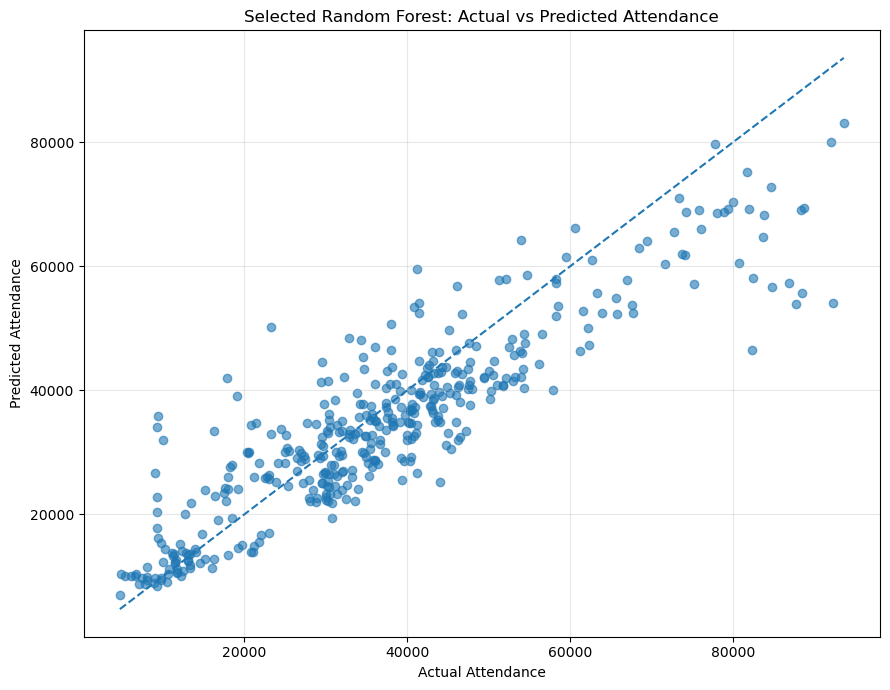

In [15]:
minimum = min(
    prediction_results["actual_attendance"].min(),
    prediction_results["predicted_attendance"].min(),
)
maximum = max(
    prediction_results["actual_attendance"].max(),
    prediction_results["predicted_attendance"].max(),
)

plt.figure(figsize=(9, 7))
plt.scatter(
    prediction_results["actual_attendance"],
    prediction_results["predicted_attendance"],
    alpha=0.6,
)
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.title("Selected Random Forest: Actual vs Predicted Attendance")
plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    IMAGES_DIR / "model_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### 11.2 Residual analysis

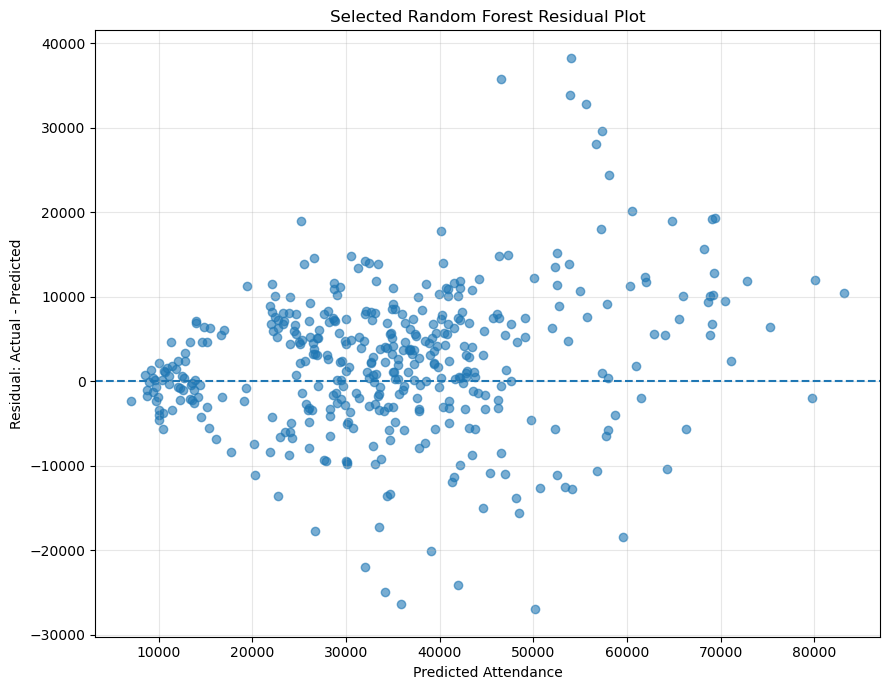

In [16]:
plt.figure(figsize=(9, 7))
plt.scatter(
    prediction_results["predicted_attendance"],
    prediction_results["residual"],
    alpha=0.6,
)
plt.axhline(y=0, linestyle="--")
plt.title("Selected Random Forest Residual Plot")
plt.xlabel("Predicted Attendance")
plt.ylabel("Residual: Actual - Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    IMAGES_DIR / "model_residuals.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

The model tends to pull extreme attendances toward the centre: it can overpredict very small crowds and underpredict blockbuster matches.

### 11.3 Performance by holdout season

In [17]:
season_performance = (
    prediction_results.groupby("season")
    .agg(
        matches=("actual_attendance", "size"),
        actual_average=("actual_attendance", "mean"),
        predicted_average=("predicted_attendance", "mean"),
        MAE=("absolute_error", "mean"),
        mean_squared_error=("squared_error", "mean"),
    )
    .reset_index()
)

season_performance["RMSE"] = (
    season_performance["mean_squared_error"] ** 0.5
)

season_performance = season_performance[
    [
        "season",
        "matches",
        "actual_average",
        "predicted_average",
        "MAE",
        "RMSE",
    ]
]

season_performance.round(2)

,season,matches,actual_average,predicted_average,MAE,RMSE
0,2024,207,37455.32,34888.03,6575.06,9135.16
1,2025,207,36985.94,35044.15,6520.93,8467.18


The selected model performs consistently across both test seasons, although predicted average attendance remains below the actual average in 2024 and 2025.

### 11.4 Performance by attendance band

In [18]:
attendance_bins = [
    0,
    20000,
    40000,
    60000,
    80000,
    float("inf"),
]

attendance_labels = [
    "Below 20,000",
    "20,000–39,999",
    "40,000–59,999",
    "60,000–79,999",
    "80,000+",
]

prediction_results["attendance_band"] = pd.cut(
    prediction_results["actual_attendance"],
    bins=attendance_bins,
    labels=attendance_labels,
    right=False,
)

attendance_band_performance = (
    prediction_results.groupby("attendance_band", observed=False)
    .agg(
        matches=("actual_attendance", "size"),
        actual_average=("actual_attendance", "mean"),
        predicted_average=("predicted_attendance", "mean"),
        MAE=("absolute_error", "mean"),
    )
    .reset_index()
)

attendance_band_performance.round(2)

,attendance_band,matches,actual_average,predicted_average,MAE
0,"Below 20,000",78,12322.76,16272.96,4989.14
1,"20,000–39,999",167,31382.42,31153.42,5193.52
2,"40,000–59,999",123,46434.66,41788.33,6564.31
3,"60,000–79,999",28,69685.57,60670.57,9559.11
4,"80,000+",18,85813.50,64739.42,21074.08


The model is most accurate for common crowd sizes and least accurate for crowds above 80,000. This indicates that blockbuster demand is not fully represented by the current feature set.

### 11.5 Largest holdout errors

In [19]:
largest_errors = (
    prediction_results.sort_values("absolute_error", ascending=False)
    [
        [
            "season",
            "round",
            "home_team",
            "away_team",
            "venue",
            "match_day",
            "actual_attendance",
            "predicted_attendance",
            "residual",
            "absolute_error",
        ]
    ]
    .head(15)
)

largest_errors.round(0)

,season,round,home_team,away_team,venue,match_day,actual_attendance,predicted_attendance,residual,absolute_error
2497,2024,15,Richmond,Hawthorn,M.C.G.,Sat,92311,54040.0,38271.0,38271.0
2773,2025,22,Collingwood,Brisbane Lions,M.C.G.,Sat,82326,46595.0,35731.0,35731.0
2440,2024,8,Geelong,Carlton,M.C.G.,Sat,87775,53866.0,33909.0,33909.0
2493,2024,14,Essendon,Carlton,M.C.G.,Sun,88510,55646.0,32864.0,32864.0
2557,2024,22,Collingwood,Carlton,M.C.G.,Sat,86879,57299.0,29580.0,29580.0
2567,2024,23,Carlton,Hawthorn,M.C.G.,Sun,84773,56648.0,28125.0,28125.0
2730,2025,17,Richmond,Adelaide,M.C.G.,Sun,23231,50230.0,-26999.0,26999.0
2417,2024,5,Richmond,St Kilda,Norwood Oval,Sun,9425,35828.0,-26403.0,26403.0
2413,2024,5,West Coast,Sydney,Summit Sports Park,Sat,9225,34169.0,-24944.0,24944.0
2665,2025,9,Collingwood,Geelong,M.C.G.,Sat,82514,58055.0,24459.0,24459.0


Most of the largest errors occur at the M.C.G., where the same venue can host both low-demand fixtures and crowds above 80,000. Venue, teams and scheduling capture broad demand, but they do not fully represent rivalries, marquee fixtures, current form or special events.

## 12. Explain the model with permutation importance

In [20]:
permutation_results = permutation_importance(
    selected_model,
    X_holdout,
    y_holdout,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame(
    {
        "feature": X_holdout.columns,
        "importance_mean": permutation_results.importances_mean,
        "importance_std": permutation_results.importances_std,
    }
).sort_values("importance_mean", ascending=False)

permutation_importance_df

,feature,importance_mean,importance_std
6,venue,6414.416319,419.009254
4,home_team,3327.236498,199.765000
5,away_team,1580.734367,107.374525
3,match_day,733.306623,107.942821
2,month,112.754669,50.467279
1,round,55.629296,31.753610
0,season,0.000000,0.000000


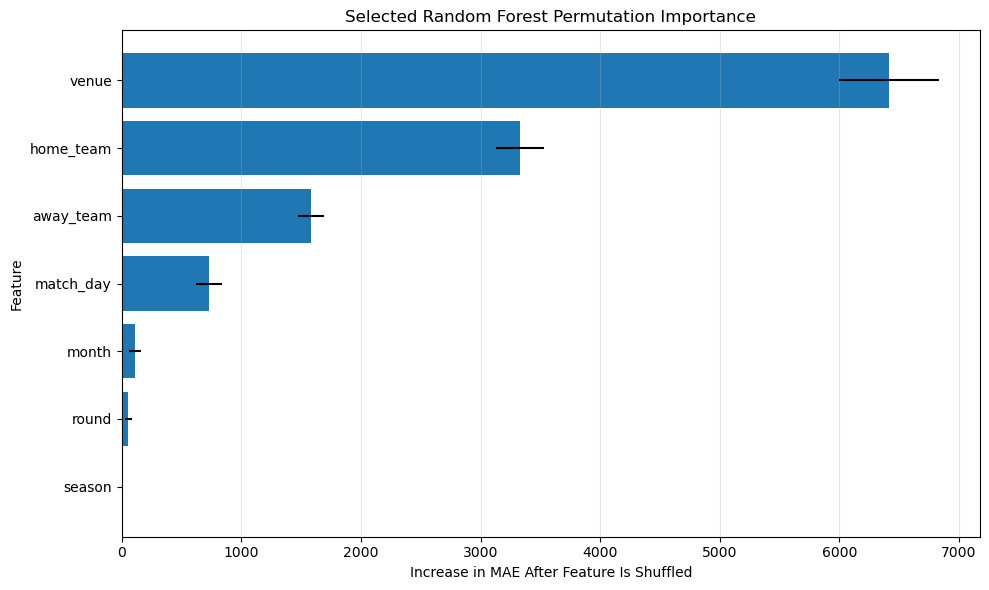

In [21]:
plot_importance = permutation_importance_df.sort_values(
    "importance_mean",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_std"],
)
plt.title("Selected Random Forest Permutation Importance")
plt.xlabel("Increase in MAE After Feature Is Shuffled")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    IMAGES_DIR / "random_forest_permutation_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Venue is the strongest predictor, followed by home team and away team. This result also explains why the model struggles at large venues: venue creates a strong base expectation, while the present features do not fully distinguish ordinary fixtures from blockbusters.

## 13. Export reproducible project artifacts

In [22]:
cv_results_df.to_csv(
    REPORTS_DIR / "candidate_model_cv_results.csv",
    index=False,
)
cv_tuning_comparison.to_csv(
    REPORTS_DIR / "random_forest_tuning_results.csv",
    index=False,
)
holdout_results_df.to_csv(
    REPORTS_DIR / "final_holdout_results.csv",
    index=False,
)
season_performance.to_csv(
    REPORTS_DIR / "season_holdout_performance.csv",
    index=False,
)
largest_errors.to_csv(
    REPORTS_DIR / "largest_prediction_errors.csv",
    index=False,
)
attendance_band_performance.to_csv(
    REPORTS_DIR / "attendance_band_performance.csv",
    index=False,
)
permutation_importance_df.to_csv(
    REPORTS_DIR / "permutation_importance.csv",
    index=False,
)

For future prediction use, the selected configuration is refitted on all eligible seasons after evaluation. The unbiased holdout metrics above still refer to the development-only evaluation model.

In [23]:
final_prediction_model = random_forest_search.best_estimator_
final_prediction_model.fit(model_df[FEATURES], model_df[TARGET])

joblib.dump(
    final_prediction_model,
    MODELS_DIR / "afl_attendance_random_forest.joblib",
)

print("Saved model:", MODELS_DIR / "afl_attendance_random_forest.joblib")

Saved model: ..\models\afl_attendance_random_forest.joblib


## 14. Limitations and next improvements

The current model does not yet include several meaningful pre-match demand drivers:

- recent team form and ladder position
- rivalry or derby indicators
- public-holiday and marquee-game indicators
- exact starting time
- ticket pricing and membership information
- weather conditions
- venue capacity utilisation
- special rounds and one-off events

These variables would be especially useful for distinguishing blockbuster matches from ordinary fixtures at the same venue.

## 15. Final conclusion

The project demonstrates a complete, leakage-aware machine-learning workflow:

1. real-world web data was collected and cleaned
2. only pre-match predictors were used
3. historical expanding-window validation guided model selection
4. hyperparameters were tuned without using the final holdout set
5. the selected model was evaluated on future seasons
6. residuals, extreme errors and feature importance were investigated
7. reusable reports, charts and a fitted pipeline were exported

The selected tuned Random Forest explains approximately **78.1%** of attendance variation in the 2024–2025 holdout seasons, with a typical error of about **6,548 attendees per match**.